# Attention Mechanism — The Pre-Transformer Era

This notebook explores the attention mechanism as it originally appeared: as a solution to the bottleneck of **Seq2Seq** networks based on RNNs (2014–2017), before the Transformer architecture (2017).

---

## 1. The Problem: Seq2Seq with a Fixed Context Vector

The **Encoder–Decoder** architecture (Sutskever et al., 2014) uses an RNN to compress the entire input sequence into **a single vector** — the *context vector* — which the Decoder uses to generate the output.

```
Input:   "The cat sat on the mat"
                  ↓
         [ Encoder RNN ]
                  ↓
          [  context c  ]   ← fixed vector (bottleneck!)
                  ↓
         [ Decoder RNN ]
                  ↓
Output:  "Le chat s'est assis sur le tapis"
```

### Why is this a problem?

- For long sentences, **a single vector must carry all the information** from the input.
- Early words tend to be "forgotten" due to the vanishing gradient problem.
- Translation quality **drops drastically** as sentence length increases.

<img src="RNN_MODEL.png" alt="RNN Model" width="600"/>

## 2. The Solution: Attention (Bahdanau et al., 2015)

The core idea: **the Decoder should not rely on a single vector**. At each decoding step, let the model "look at" all the Encoder hidden states and decide **which ones are most relevant**.

### Architecture with Attention

```
Input:    x₁   x₂   x₃   x₄
           ↓    ↓    ↓    ↓
          h₁   h₂   h₃   h₄   ← Encoder hidden states
           ↘    ↓    ↓   ↙
         α₁   α₂   α₃  α₄     ← attention weights (sum to 1)
              ↓
        c_t = Σ αᵢ · hᵢ        ← dynamic context vector
              ↓
    [ Decoder state s_t ]      ← combines previous token + past state
              ↓
  logits_t = W_o[s_t ; c_t] + b_o
              ↓
     p(y_t | y_{<t}, x) = softmax(logits_t)
              ↓
        ŷ_t = argmax p(y_t | y_{<t}, x)
```

### Step-by-step prediction of the next token

At decoding step $t$, the model predicts the next word by following these steps:

1. Use the previous generated word $y_{t-1}$ and the previous decoder state $s_{t-1}$ to compute the new decoder state $s_t$.
2. Compare $s_t$ with every encoder hidden state $h_i$ to produce attention scores $e_{t,i}$.
3. Apply softmax to convert these scores into attention weights $\alpha_{t,i}$.
4. Build the context vector $c_t$ as the weighted sum of encoder states.
5. Combine $s_t$ and $c_t$ to produce vocabulary logits.
6. Apply softmax over the full vocabulary to obtain the probability of every possible next token.
7. Select the next token, usually with argmax or sampling.

### Mathematical formulation

**Step 1 — Decoder state update**

$$s_t = \mathrm{RNN}(s_{t-1}, E(y_{t-1}), c_{t-1})$$

This produces the decoder hidden state used to query the encoder memory.

**Step 2 — Score** (how relevant is state $h_i$ to the current decoder step $s_t$):

$$e_{t,i} = v^\top \tanh(W_a s_t + U_a h_i)$$

**Step 3 — Normalisation** (softmax to obtain weights that sum to 1):

$$\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_j \exp(e_{t,j})}$$

**Step 4 — Context vector** (weighted average of encoder states):

$$c_t = \sum_i \alpha_{t,i} h_i$$

**Step 5 — Next-token logits**

$$z_t = W_o [s_t ; c_t] + b_o$$

where $[s_t ; c_t]$ denotes concatenation of the decoder state and the context vector.

**Step 6 — Probability of the next token**

$$p(y_t = w \mid y_{<t}, x) = \mathrm{softmax}(z_t)_w$$

for each vocabulary word $w$. The predicted next token is then

$$\hat{y}_t = \arg\max_w p(y_t = w \mid y_{<t}, x)$$

<img src="RNN_ATTENTION.png" alt="RNN Attention" width="600"/>

## 3. Simple NumPy Implementation

Let's implement the three steps of Bahdanau attention from scratch, without any deep learning framework.

In [2]:
import numpy as np
np.random.seed(42)

# Dimensions
d_enc = 4   # encoder hidden state dimension
d_dec = 4   # decoder hidden state dimension
d_att = 3   # attention space dimension
T_enc = 4   # input sequence length

# Learnable parameters (randomly initialised here)
Wa = np.random.randn(d_att, d_dec) * 0.1   # projects decoder state
Ua = np.random.randn(d_att, d_enc) * 0.1   # projects encoder states
v  = np.random.randn(d_att) * 0.1          # scoring vector

# Encoder hidden states (simulated)
# Each row is h_i for word i
H = np.array([
    [0.1, -0.3,  0.5,  0.2],   # h1 → "The"
    [0.8,  0.6, -0.2,  0.9],   # h2 → "cat"
    [0.3, -0.1,  0.7, -0.4],   # h3 → "sat"
    [-0.2, 0.4, -0.5,  0.1],   # h4 → "on"
])  # shape: (T_enc, d_enc)

# Current decoder hidden state (when generating "chat")
s_prev = np.array([0.5, 0.3, -0.1, 0.7])  # shape: (d_dec,)

def bahdanau_attention(H, s_prev, Wa, Ua, v):
    """Returns attention weights alpha and context vector c."""
    # Step 1: scores  e_i = v · tanh(Wa·s + Ua·h_i)
    proj_dec = Wa @ s_prev          # (d_att,)
    proj_enc = H @ Ua.T             # (T_enc, d_att)
    scores = np.tanh(proj_enc + proj_dec) @ v  # (T_enc,)

    # Step 2: softmax
    exp_scores = np.exp(scores - scores.max())  # numerical stability
    alphas = exp_scores / exp_scores.sum()       # (T_enc,)

    # Step 3: context vector
    c = alphas @ H  # (d_enc,)
    return alphas, c

alphas, context = bahdanau_attention(H, s_prev, Wa, Ua, v)

words = ['"The"', '"cat"', '"sat"', '"on"']
print('Attention weights (α):')
for w, a in zip(words, alphas):
    bar = '█' * int(a * 40)
    print(f'  {w:10s}: {a:.4f}  {bar}')
print(f'\nSum of weights: {alphas.sum():.6f} (should be 1.0)')
print(f'Context vector c: {context.round(4)}')

Attention weights (α):
  "The"     : 0.2499  █████████
  "cat"     : 0.2514  ██████████
  "sat"     : 0.2473  █████████
  "on"      : 0.2514  ██████████

Sum of weights: 1.000000 (should be 1.0)
Context vector c: [0.25   0.1516 0.1221 0.2024]


## 4. Visualising Attention Weights — Alignment Matrix

One of the most important visualisations of attention is the **alignment matrix**: for each token generated by the decoder (Y axis), which encoder tokens received the most attention (X axis).

This reveals how the model "aligns" tokens across languages — often capturing real linguistic correspondences.

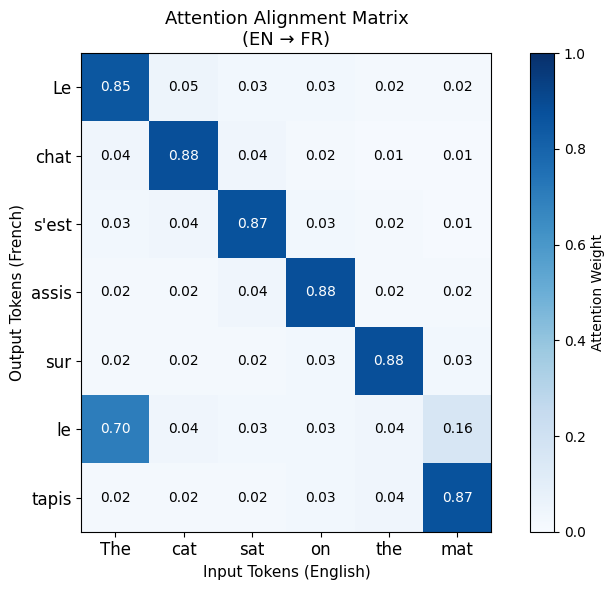

In [3]:
import matplotlib.pyplot as plt
# Simulates attention weights for an EN → FR translation
# Row i = decoder step i; Column j = encoder token j
source = ['The', 'cat', 'sat', 'on', 'the', 'mat']
target = ['Le', 'chat', 's\'est', 'assis', 'sur', 'le', 'tapis']

# Realistic attention matrix for this translation
attention = np.array([
    [0.85, 0.05, 0.03, 0.03, 0.02, 0.02],  # Le    → The
    [0.04, 0.88, 0.04, 0.02, 0.01, 0.01],  # chat  → cat
    [0.03, 0.04, 0.87, 0.03, 0.02, 0.01],  # s'est → sat
    [0.02, 0.02, 0.04, 0.88, 0.02, 0.02],  # assis → sat
    [0.02, 0.02, 0.02, 0.03, 0.88, 0.03],  # sur   → on
    [0.70, 0.04, 0.03, 0.03, 0.04, 0.16],  # le    → the / mat
    [0.02, 0.02, 0.02, 0.03, 0.04, 0.87],  # tapis → mat
])

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(attention, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(len(source)))
ax.set_yticks(range(len(target)))
ax.set_xticklabels(source, fontsize=12)
ax.set_yticklabels(target, fontsize=12)
ax.set_xlabel('Input Tokens (English)', fontsize=11)
ax.set_ylabel('Output Tokens (French)', fontsize=11)
ax.set_title('Attention Alignment Matrix\n(EN → FR)', fontsize=13)

for i in range(len(target)):
    for j in range(len(source)):
        color = 'white' if attention[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{attention[i, j]:.2f}', ha='center', va='center',
                color=color, fontsize=10)

plt.colorbar(im, ax=ax, label='Attention Weight')
plt.tight_layout()
plt.show()

## 5. Multiplicative Attention (Luong et al., 2015)

Shortly after Bahdanau, Luong et al. proposed simpler and more efficient variants.

| Type | Score Formula | Complexity |
|------|---------------|-----------|
| **Dot-product** | $e_i = s^\top h_i$ | O(1) |
| **General** | $e_i = s^\top W h_i$ | O(d²) |
| **Additive (Bahdanau)** | $e_i = v^\top \tanh(W_a s + U_a h_i)$ | O(d²) |

The **dot-product** is extremely simple: just the inner product between the decoder state and each encoder state.

> This idea of the inner product as a similarity score is exactly what the Transformer generalised into **Scaled Dot-Product Attention**.

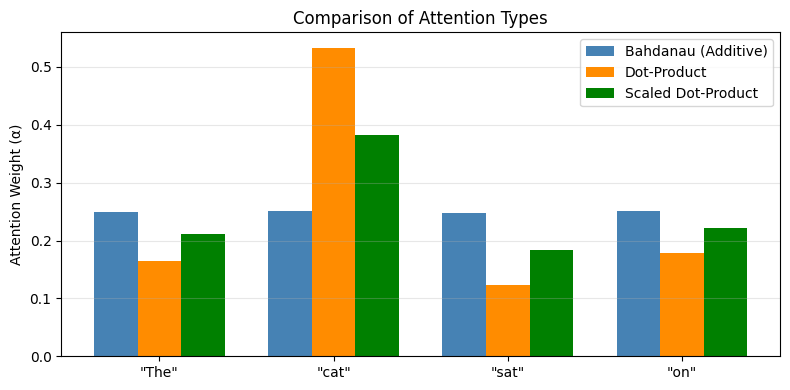

In [4]:
def dot_product_attention(H, s):
    """Simple inner-product attention."""
    scores = H @ s                                 # (T,)
    exp_s  = np.exp(scores - scores.max())
    alphas = exp_s / exp_s.sum()                   # softmax
    c      = alphas @ H
    return alphas, c

def scaled_dot_product_attention(H, s):
    """Scaled dot-product — direct precursor of the Transformer."""
    d = H.shape[1]
    scores = (H @ s) / np.sqrt(d)                 # scale by √d
    exp_s  = np.exp(scores - scores.max())
    alphas = exp_s / exp_s.sum()
    c      = alphas @ H
    return alphas, c

# Compare all three methods on the same data
alpha_bahdanau, _ = bahdanau_attention(H, s_prev, Wa, Ua, v)
alpha_dot,      _ = dot_product_attention(H, s_prev)
alpha_scaled,   _ = scaled_dot_product_attention(H, s_prev)

x = np.arange(len(words))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width, alpha_bahdanau, width, label='Bahdanau (Additive)', color='steelblue')
ax.bar(x,         alpha_dot,      width, label='Dot-Product',          color='darkorange')
ax.bar(x + width, alpha_scaled,   width, label='Scaled Dot-Product',   color='green')

ax.set_xticks(x)
ax.set_xticklabels(words)
ax.set_ylabel('Attention Weight (α)')
ax.set_title('Comparison of Attention Types')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Why Scale by √d?

When the dimension `d` is large, the inner product tends to grow in magnitude, pushing the softmax into regions of **near-zero gradients** (saturation).

Dividing by $\sqrt{d}$ keeps the scores in a range where the softmax still has useful gradients.

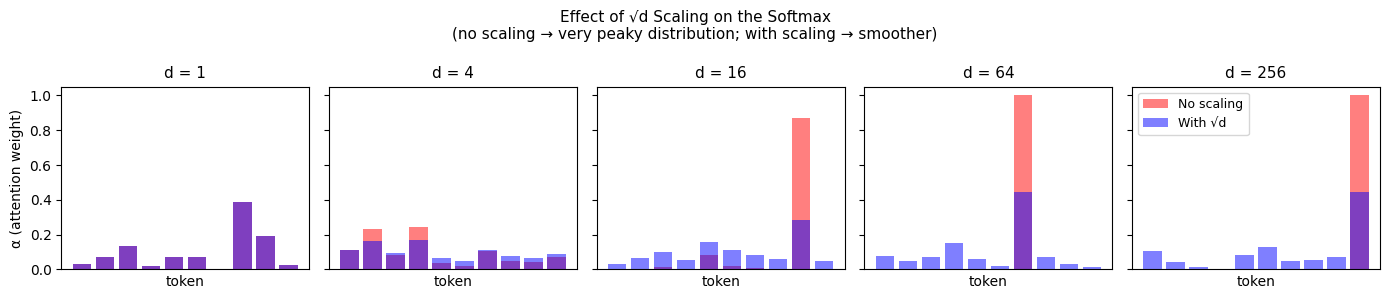

In [5]:
def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

dims = [1, 4, 16, 64, 256]
fig, axes = plt.subplots(1, len(dims), figsize=(14, 3), sharey=True)

np.random.seed(7)
for ax, d in zip(axes, dims):
    q = np.random.randn(d)
    K = np.random.randn(10, d)   # 10 keys

    scores_raw    = K @ q
    scores_scaled = K @ q / np.sqrt(d)

    ax.bar(range(10), softmax(scores_raw),    alpha=0.5, label='No scaling', color='red')
    ax.bar(range(10), softmax(scores_scaled), alpha=0.5, label='With √d',    color='blue')
    ax.set_title(f'd = {d}', fontsize=11)
    ax.set_xlabel('token')
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

axes[0].set_ylabel('α (attention weight)')
axes[-1].legend(fontsize=9)
fig.suptitle('Effect of √d Scaling on the Softmax\n(no scaling → very peaky distribution; with scaling → smoother)',
             fontsize=11)
plt.tight_layout()
plt.show()

## 7. Attention as Soft vs. Hard Lookup

We can think of attention as a **differentiable memory lookup**:

| Concept | Python Dictionary | Attention |
|---------|-------------------|-----------|
| **Query** | lookup key | decoder state `s` |
| **Keys** | dict keys | projections of states `hᵢ` |
| **Values** | dict values | encoder states `hᵢ` themselves |
| **Output** | `dict[key]` (hard) | weighted sum (soft) |

The fundamental difference: in a dictionary, the lookup is **discrete** (0 or 1). In attention, it is **continuous** — the model smoothly interpolates across all values, enabling **backpropagation**.

##### Source: https://medium.com/@manindersingh120996/the-detailed-explanation-of-self-attention-in-simple-words-dec917f83ef3

In [10]:
# Illustration: hard lookup vs. soft attention
src_words  = ['The', 'cat', 'sat', 'on', 'mat']
embeddings = np.random.randn(5, 3)  # 5 words, dimension 3

query = embeddings[1]  # use "cat" vector as query
print(embeddings@query)

# Hard lookup (exact index — not differentiable)
idx_hard = np.argmax(embeddings @ query)

# Soft attention (differentiable)
scores      = embeddings @ query
exp_s       = np.exp(scores - scores.max())
alphas_soft = exp_s / exp_s.sum()
soft_result = alphas_soft @ embeddings

print('Hard lookup: retrieves only 1 element')
print(f'  Index: {idx_hard} → "{src_words[idx_hard]}" (α=1.0 for this one, 0 for the rest)')

print('\nSoft attention: combines all elements')
for w, a in zip(src_words, alphas_soft):
    print(f'  {w:8s}: α = {a:.4f}')

print(f'\nSoft result: smooth interpolation = {soft_result.round(4)}')
print('→ Gradient flows through ALL encoder states!')

[ 0.44181492  1.70039877 -1.39672162  0.51455547  0.30642705]
Hard lookup: retrieves only 1 element
  Index: 1 → "cat" (α=1.0 for this one, 0 for the rest)

Soft attention: combines all elements
  The     : α = 0.1509
  cat     : α = 0.5311
  sat     : α = 0.0240
  on      : α = 0.1623
  mat     : α = 0.1318

Soft result: smooth interpolation = [-0.4212 -1.0921  0.1051]
→ Gradient flows through ALL encoder states!


## 8. Timeline — Attention Before the Transformer

```
2014 ── Seq2Seq (Sutskever)       →  Encoder-Decoder with fixed vector
           │
2015 ── Bahdanau Attention        →  Additive score, bidirectional RNN
           │
2015 ── Luong Attention           →  Dot-product and general scores
           │
2016 ── Copy Mechanism            →  Attention to copy tokens from input
           │
2016 ── Pointer Networks          →  Attention points to input positions
           │
2017 ── Transformer ◄─────────────  "Attention is All You Need"
           │                         (no RNNs, multi-head, self-attention)
```

## Summary

| Concept | What we learned |
|---------|------------------|
| **Bottleneck** | A single context vector does not scale to long sequences |
| **Attention** | *Dynamic* context vector via weighted average of encoder states |
| **Score** | Measures the relevance of each encoder state to the current decoder step |
| **Softmax** | Normalises scores into weights that sum to 1 |
| **Differentiable** | Gradients flow through all states — this is the key insight |
| **Scaled dot-product** | The simplification that the Transformer inherits directly |

> The Transformer (2017) took this idea to the extreme: it **eliminated RNNs entirely** and processed all positions in parallel using only attention — see the `09_transformer.ipynb` notebook for the continuation.